## 定义模型

In [1]:
import os
from langchain_community.chat_models import ChatTongyi
llm = ChatTongyi(
    model="qwen3-235b-a22b-instruct-2507",  # 推荐使用 qwen-max 或 qwen-plus 以获得更好的指令遵循能力
    dashscope_api_key=os.getenv("DASHSCOPE_API_KEY"),
    temperature=0.88    # 结构化输出建议将温度设为 0
)

## 定义节点

In [2]:
from typing_extensions import TypedDict, Annotated
from pydantic import BaseModel, Field
from typing import Literal

class State(TypedDict):
    joke: str
    topic: str
    feedback: str
    funny_or_not: str


# Schema for structured output to use in evaluation
class Feedback(BaseModel):
    grade: Literal["好笑", "不好笑"] = Field(
        description="判断笑话是否好笑.",
    )
    feedback: str = Field(
        description="如果不好笑，给出简短理由和改进建议.",
    )


# Augment the LLM with schema for structured output
evaluator = llm.with_structured_output(Feedback)


# Nodes
def llm_call_generator(state: State):
    """LLM generates a joke"""

    if state.get("feedback"):
        msg = llm.invoke(
            f"写一个关于{state['topic']}的简短笑话，考虑反馈建议: {state['feedback']}，只输出笑话内容，不做分析", reasoning=False
        )
    else:
        msg = llm.invoke(f"写一个关于{state['topic']}的简短笑话", reasoning=False)
    msg.pretty_print() 
    return {"joke": msg.content}


def llm_call_evaluator(state: State):
    """LLM evaluates the joke"""

    grade = evaluator.invoke(f"给笑话打分并简短评价，评判标准严格。笑话：{state['joke']}", reasoning=False)
    print(f"\n\n[Grade: {grade.grade}, Feedback: {grade.feedback}]\n\n")
    return {"funny_or_not": grade.grade, "feedback": grade.feedback}


# Conditional edge function to route back to joke generator or end based upon feedback from the evaluator
def route_joke(state: State):
    """Route back to joke generator or end based upon feedback from the evaluator"""

    if state["funny_or_not"] == "好笑":
        return "Accepted"
    elif state["funny_or_not"] == "不好笑":
        return "Rejected + Feedback"

## 构建图

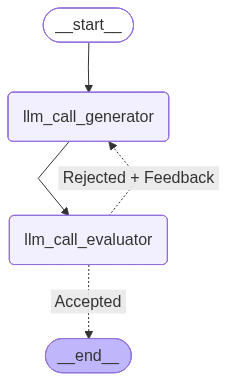

In [3]:
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

# Build workflow
optimizer_builder = StateGraph(State)

# Add the nodes
optimizer_builder.add_node("llm_call_generator", llm_call_generator)
optimizer_builder.add_node("llm_call_evaluator", llm_call_evaluator)

# Add edges to connect nodes
optimizer_builder.add_edge(START, "llm_call_generator")
optimizer_builder.add_edge("llm_call_generator", "llm_call_evaluator")
optimizer_builder.add_conditional_edges(
    "llm_call_evaluator",
    route_joke,
    {  # Name returned by route_joke : Name of next node to visit
        "Accepted": END,
        "Rejected + Feedback": "llm_call_generator",
    },
)

# Compile the workflow
optimizer_workflow = optimizer_builder.compile()

# Show the workflow
display(Image(optimizer_workflow.get_graph().draw_mermaid_png()))

## 运行

In [4]:
# Invoke
state = optimizer_workflow.invoke({"topic": "工作，老板"})
print(state["joke"])

================================== Ai Message ==================================

有一天，老板走进办公室，看到员工小李在认真工作。

老板满意地点点头：“小李啊，你最近表现不错，连续三天准时上班，值得表扬！”

小李抬起头，一脸疲惫：“谢谢老板……其实我根本没回家，一直在公司加班。”

老板愣了一下，赶紧说：“那你快回去休息吧！”

小李叹了口气：“我也想……但工位太舒服了，舍不得走。” 😂


[Grade: 不好笑, Feedback: 笑话情节平淡，缺乏意外转折或夸张元素，笑点薄弱。建议增强反差或加入更荒诞的细节来提升幽默感。]


================================== Ai Message ==================================

老板拍着我的肩膀说：“这个月业绩第一，奖励你带薪休假三天！”  
我感动得差点哭出来。  
结果他递给我一张调岗通知：“恭喜你调去火葬场上班，毕竟你天天加班，都快死了——他们急需有经验的。”


[Grade: 不好笑, Feedback: 笑话试图通过反转制造幽默，但主题涉及死亡和职场压榨，容易引发负面情绪而非笑声。建议调整方向，避免敏感话题，增强情节的荒诞性或语言的巧妙性以提升幽默感。]


================================== Ai Message ==================================

老板说加班到凌晨的员工最有奉献精神。  
我问他：“那通宵的呢？”  
他说：“通宵的我们已经刻在公司纪念碑上了。”  
我吓得一激灵，他哈哈大笑：“骗你的，那是上季度KPI达标墙！”


[Grade: 好笑, Feedback: 笑话利用了预期违背，从“纪念碑”的死亡暗示转向“KPI达标墙”的职场调侃，反差感强且符合职场语境，结尾转折自然，有讽刺幽默感。]


老板说加班到凌晨的员工最有奉献精神。  
我问他：“那通宵的呢？”  
他说：“通宵的我们已经刻在公司纪念碑上了。”  
我吓得一激灵，他哈哈大笑：“骗你的，那是上季度KPI达标墙！”
